# Price Forecasting — Model Training
Change settings in the **Settings** cell, then run cells top-to-bottom.
Training scripts live in `src/models/` — this notebook just calls them and shows results.

In [21]:
# ── Settings ─────────────────────────────────────────────────────────────────
import sys, pandas as pd
from datetime import date, timedelta
from pathlib import Path

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

# END_DATE: latest date retrievable from the TIGGE archive (48-hour embargo).
# Workers in cell-3 will download any missing dates up to this target.
# After merging, training features use all dates present in weather_ensemble.parquet.
END_DATE = (date.today() - timedelta(days=2)).isoformat()

# Validation splits — kept fixed so KPIs remain comparable across retraining runs.
# Advance these manually when you want to shift the evaluation window forward.
VAL_START_DEFAULT     = "2026-05-01"   # TRL Daily + TRE
VAL_START_TRL_WEEKLY  = "2026-04-06"   # TRL Weekly (needs more weeks at weekly resolution)

# Quantiles to train
QUANTILES = [0.1, 0.25, 0.5, 0.75, 0.9]

# TRE two-stage thresholds (CHF/MWh)
TRE_THRESHOLD_POS =  300.0   # above → extreme positive
TRE_THRESHOLD_NEG = -200.0   # below → extreme negative

print(f"  END_DATE (target): {END_DATE}  (today − 2 days, TIGGE embargo)")
print(f"  val_start default: {VAL_START_DEFAULT}")
print(f"  val_start weekly : {VAL_START_TRL_WEEKLY}")

  END_DATE (target): 2026-05-27  (today − 2 days, TIGGE embargo)
  val_start default: 2026-05-01
  val_start weekly : 2026-04-06


In [22]:
# ── Apply settings to config.yaml ────────────────────────────────────────────
import sys, subprocess, re, yaml
from pathlib import Path

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

cfg_path = ROOT / "config" / "config.yaml"
with open(cfg_path) as f:
    cfg = yaml.safe_load(f)

cfg["training"]["end_date"]  = END_DATE
cfg["training"]["val_start"] = VAL_START_DEFAULT
cfg["training"]["quantiles"] = QUANTILES
cfg["models"]["trl_weekly"]["val_start"] = VAL_START_TRL_WEEKLY
cfg["models"]["tre"]["extreme_threshold_pos"] = TRE_THRESHOLD_POS
cfg["models"]["tre"]["extreme_threshold_neg"] = TRE_THRESHOLD_NEG

with open(cfg_path, "w") as f:
    yaml.dump(cfg, f, default_flow_style=False, sort_keys=False)

print("Config updated:")
print(f"  end_date         : {END_DATE}")
print(f"  val_start        : {VAL_START_DEFAULT}  (TRL Weekly: {VAL_START_TRL_WEEKLY})")
print(f"  quantiles        : {QUANTILES}")
print(f"  TRE threshold pos: > {TRE_THRESHOLD_POS} CHF/MWh")
print(f"  TRE threshold neg: < {TRE_THRESHOLD_NEG} CHF/MWh")

Config updated:
  end_date         : 2026-05-27
  val_start        : 2026-05-01  (TRL Weekly: 2026-04-06)
  quantiles        : [0.1, 0.25, 0.5, 0.75, 0.9]
  TRE threshold pos: > 300.0 CHF/MWh
  TRE threshold neg: < -200.0 CHF/MWh


In [23]:
# ── ECMWF weather (background, ~2 min per new date) ──────────────────────────
# Launches background workers for any dates not yet downloaded.
# Check progress with the --status cell below; merge when done.
# Update END_DATE in Settings first if needed.
result = subprocess.run(
    [sys.executable, str(ROOT / "src/data/ecds_parallel_launch.py"), "--status"],
    capture_output=True, text=True, cwd=str(ROOT)
)
print(result.stdout)

subprocess.Popen(
     [sys.executable, str(ROOT / "src/data/ecds_parallel_launch.py"), "--workers", "2"],
     cwd=str(ROOT)
     )
print("Workers launched — re-run this cell to check status, then merge when done.")


subprocess.run([sys.executable, str(ROOT / "src/data/ecds_parallel_launch.py"), "--merge"],
               cwd=str(ROOT), capture_output=False)

Overall: 1608 / 1608 dates done (100.0%)

  main parquet : 1608 dates
  weather_ensemble_chunk_00.parquet: 1 dates  (2026-05-24 to 2026-05-24)

  ecds_chunk_00.log: 2026-05-29 10:06:45  INFO      Done.
  ecds_chunk_01.log: 2026-05-29 10:06:24  INFO      Done.
  ecds_chunk_02.log: 2026-05-09 18:03:57  INFO      Done.
  ecds_chunk_03.log: 2026-05-09 15:32:20  INFO      Done.
  ecds_chunk_04.log: 2026-05-09 05:19:52  INFO      Done.
  ecds_chunk_05.log: 2026-05-06 10:04:51  INFO      Done.

Workers launched — re-run this cell to check status, then merge when done.


CompletedProcess(args=['c:\\Users\\ThijsAntoniedeBoer\\OneDrive - HELION\\Dokumente\\python-projects\\standard_env\\Scripts\\python.exe', 'C:\\Users\\ThijsAntoniedeBoer\\OneDrive - HELION\\Dokumente\\Price Forecasting\\src\\data\\ecds_parallel_launch.py', '--merge'], returncode=0)

In [24]:
# ── TRE prices (Swissgrid) ────────────────────────────────────────────────────
import subprocess, sys
from pathlib import Path
ROOT = Path().resolve().parent
result = subprocess.run(
    [sys.executable, str(ROOT / "src/data/update_tre_prices.py")],
    capture_output=True, text=True, cwd=str(ROOT)
)
print(result.stdout)
if result.returncode != 0:
    print("ERROR:", result.stderr[-500:])

Found 5 TRE file(s) on Swissgrid:
  2026-01-TRE-Ergebnis.csv
  2026-02-TRE-Ergebnis.csv
  2026-03-TRE-Ergebnis.csv
  2026-04-TRE-Ergebnis.csv.zip
  2026-05-TRE-Ergebnis.csv.zip
  Skipping 2026-01-TRE-Ergebnis.csv (already in parquet)
  Skipping 2026-02-TRE-Ergebnis.csv (already in parquet)
  Skipping 2026-03-TRE-Ergebnis.csv (already in parquet)
  Skipping 2026-04-TRE-Ergebnis.csv.zip (already in parquet)

Saved 234450 rows to tre_slots.parquet
Latest slot: 2026-05-29 05:00:00+00:00



In [25]:
# ── Spot prices + TRL Weekly/Daily + reservoir levels (from Helion dashboard) ─────────────────────────────────────────────────────────
result = subprocess.run(
    [sys.executable, str(ROOT / "src/data/market_data.py")],
    capture_output=True, text=True, cwd=str(ROOT)
)
clean = "\n".join(
    re.sub(r'^\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2},\d+\s+\w+\s+', '', l)
    for l in (result.stdout + result.stderr).splitlines()
)
print(clean if clean.strip() else "(no output)")
if result.returncode != 0:
    print("ERROR:", result.stderr[-500:])

Fetching market data from GitHub ...
processedAt: 2026-05-29T05:08:05.169845+00:00
Parsing TRL Weekly ...
Saved 528 rows â†’ trl_weekly.parquet
Parsing TRL Daily ...
Saved 18966 rows â†’ trl_daily.parquet
Parsing TRE Slots ...
Saved 234258 rows â†’ tre_slots.parquet
Parsing Spot Hourly ...
Saved 38640 rows â†’ spot_hourly.parquet
Parsing Reservoir Levels ...
Fetching reservoir levels from opendata.swiss ...
Saved 1378 rows â†’ reservoir_levels.parquet
Done.


---
## Data update
Run before retraining to pull the latest prices and weather.
Run cells in order — Rebuild features must come after all source data is updated.

| Step | Cell | Source | Speed |
|---|---|---|---|
| ECMWF weather | 3 | ECDS archive | ~2 min/date, background |
| TRE prices | 4 | Swissgrid tenders page | ~30s |
| Spot + TRL + reservoir | 5 | Helion dashboard (GitHub) | ~5s |
| Rebuild features | 6 | local computation | ~15s |

In [26]:
# ── Rebuild features ─────────────────────────────────────────────────────────
result = subprocess.run(
    [sys.executable, str(ROOT / "src/data/feature_store.py")],
    capture_output=True, text=True, cwd=str(ROOT)
)
clean = "\n".join(
    re.sub(r'^\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2},\d+\s+\w+\s+', '', l)
    for l in (result.stdout + result.stderr).splitlines()
)
print(clean if clean.strip() else "Done.")
if result.returncode != 0:
    print("ERROR:", result.stderr[-500:])

Building TRL Weekly features ...
C:\Users\ThijsAntoniedeBoer\OneDrive - HELION\Dokumente\Price Forecasting\src\data\feature_store.py:427: RuntimeWarning: All-NaN slice encountered
  daily_spreads[:, d] = np.nanmax(day_p, axis=1) - np.nanmin(day_p, axis=1)
C:\Users\ThijsAntoniedeBoer\OneDrive - HELION\Dokumente\Price Forecasting\src\data\feature_store.py:430: RuntimeWarning: Mean of empty slice
  "spot_baseload_mean":     np.nanmean(prices, axis=1),
C:\Users\ThijsAntoniedeBoer\OneDrive - HELION\Dokumente\Price Forecasting\src\data\feature_store.py:431: RuntimeWarning: Mean of empty slice
  "spot_peakload_mean":     np.nanmean(np.where(is_peak, prices, np.nan), axis=1),
C:\Users\ThijsAntoniedeBoer\OneDrive - HELION\Dokumente\Price Forecasting\src\data\feature_store.py:432: RuntimeWarning: All-NaN slice encountered
  "spot_max":               np.nanmax(prices, axis=1),
C:\Users\ThijsAntoniedeBoer\OneDrive - HELION\Dokumente\Price Forecasting\src\data\feature_store.py:433: RuntimeWarning: 

---
## Train models
Run individually or all at once. Output shows pinball loss per quantile.

In [27]:
import subprocess, re

_LOG_PREFIX = re.compile(r'^\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2},\d+\s+\w+\s+')

def run_script(script: str) -> tuple[str, list[dict]]:
    """Run a training script, stream output, return (stdout, parsed pinball rows)."""
    result = subprocess.run(
        [sys.executable, str(ROOT / script)],
        capture_output=True, text=True, cwd=str(ROOT)
    )
    out = result.stdout + result.stderr
    clean = "\n".join(_LOG_PREFIX.sub("", l) for l in out.splitlines())
    print(clean)
    # Parse pinball lines — two formats:
    #   new (TRL Weekly): "q=0.10  n_est=142  pinball_es=...  pinball_kpi=17.19"
    #   old (TRL Daily / TRE): "q=0.10  pinball=4.03  best_iter=69"
    rows = []
    for line in out.splitlines():
        m = re.search(r'\[(\w+)/(\w+)\]', line)
        if m:
            cur_dir = m.group(2)
        m2 = re.search(r'q=(\d\.\d+).*pinball_kpi=([\d\.]+)', line)
        if not m2:
            m2 = re.search(r'q=(\d\.\d+)\s+pinball=([\d\.]+)', line)
        if m2:
            rows.append({"direction": cur_dir,
                         "q": float(m2.group(1)),
                         "pinball": float(m2.group(2))})
    return out, rows

In [28]:
print("=" * 60)
print("TRL Weekly")
print("=" * 60)
_, rows_weekly = run_script("src/models/trl_weekly_model.py")

TRL Weekly
[trl_weekly/up] train=118  es_val=84  kpi_val=9
q=0.10  CV best_iters=[32, 1, 23]  â†’ n_estimators=30
q=0.10  n_est=30  pinball_es=15.5786 (norm=0.0629)  pinball_kpi=23.2301 (norm=0.0443)
q=0.25  CV best_iters=[1, 24, 265]  â†’ n_estimators=116
q=0.25  n_est=116  pinball_es=20.4463 (norm=0.0825)  pinball_kpi=29.3976 (norm=0.0561)
q=0.50  CV best_iters=[11, 50, 257]  â†’ n_estimators=127
q=0.50  n_est=127  pinball_es=39.2269 (norm=0.1583)  pinball_kpi=32.2737 (norm=0.0616)
q=0.75  CV best_iters=[1, 63, 272]  â†’ n_estimators=134
q=0.75  n_est=134  pinball_es=44.5423 (norm=0.1797)  pinball_kpi=32.9714 (norm=0.0629)
q=0.90  CV best_iters=[4, 97, 173]  â†’ n_estimators=109
q=0.90  n_est=109  pinball_es=41.3490 (norm=0.1668)  pinball_kpi=34.3410 (norm=0.0655)
Saved â†’ trl_weekly_up.pkl
[trl_weekly/down] train=118  es_val=84  kpi_val=9
q=0.10  CV best_iters=[1, 25, 6]  â†’ n_estimators=30
q=0.10  n_est=30  pinball_es=152.8583 (norm=0.1642)  pinball_kpi=73.8042 (norm=0.0651)
q=0.

In [29]:
print("=" * 60)
print("TRL Daily")
print("=" * 60)
_, rows_daily = run_script("src/models/trl_daily_model.py")

TRL Daily
[trl_daily/up] train=5196  val=185
q=0.10  pinball=0.7247 (norm=0.0798)  best_iter=65
q=0.25  pinball=1.5818 (norm=0.1741)  best_iter=97
q=0.50  pinball=2.5277 (norm=0.2782)  best_iter=79
q=0.75  pinball=3.3250 (norm=0.3659)  best_iter=113
q=0.90  pinball=3.1837 (norm=0.3504)  best_iter=116
Saved â†’ trl_daily_up.pkl
[trl_daily/down] train=4859  val=178
q=0.10  pinball=5.3476 (norm=0.0714)  best_iter=151
q=0.25  pinball=10.1687 (norm=0.1359)  best_iter=98
q=0.50  pinball=14.7300 (norm=0.1968)  best_iter=71
q=0.75  pinball=14.3611 (norm=0.1919)  best_iter=175
q=0.90  pinball=11.1960 (norm=0.1496)  best_iter=129
Saved â†’ trl_daily_down.pkl

direction  quantile  pinball_kpi  pinball_kpi_norm
       up      0.10     0.724651          0.079750
       up      0.25     1.581824          0.174085
       up      0.50     2.527714          0.278184
       up      0.75     3.324973          0.365925
       up      0.90     3.183720          0.350380
     down      0.10     5.347608    

In [30]:
print("=" * 60)
print("TRE (two-stage)")
print("=" * 60)
_, rows_tre = run_script("src/models/tre_model.py")

TRE (two-stage)
[tre/pos] train=3673 (extreme=76, 2.1%)  val=898 (extreme=19, 2.1%)
Classifier  AUC=0.8592  best_iter=16
Normal  train=3597 val=879  |  Extreme  train=76 val=19
q=0.10  pinball=6.9026 (norm=0.0382)
q=0.25  pinball=15.5182 (norm=0.0858)
q=0.50  pinball=27.6282 (norm=0.1527)
q=0.75  pinball=37.8070 (norm=0.2090)
q=0.90  pinball=41.7455 (norm=0.2308)
Saved -> tre_pos.pkl
[tre/neg] train=2342 (extreme=74, 3.2%)  val=382 (extreme=26, 6.8%)
Classifier  AUC=0.9239  best_iter=9
Normal  train=2268 val=356  |  Extreme  train=74 val=26
q=0.10  pinball=38.3333 (norm=1.6530)
q=0.25  pinball=55.7775 (norm=2.4052)
q=0.50  pinball=51.4314 (norm=2.2178)
q=0.75  pinball=38.0552 (norm=1.6410)
q=0.90  pinball=20.3779 (norm=0.8787)
Saved -> tre_neg.pkl

direction  quantile  pinball_kpi  pinball_kpi_norm  clf_auc
      pos      0.10     6.902566          0.038161 0.859170
      pos      0.25    15.518221          0.085792 0.859170
      pos      0.50    27.628247          0.152742 0.859170
 

---
## Results — Pinball loss on validation set

In [31]:
import pandas as pd

def pinball_table(rows, model_name):
    if not rows:
        print(f"{model_name}: no results parsed")
        return
    df = pd.DataFrame(rows)
    pt = df.pivot(index="direction", columns="q", values="pinball").round(2)
    pt.columns = [f"q{c:.2f}" for c in pt.columns]
    print(f"\n{'─'*50}")
    print(f"  {model_name}  — pinball loss (val set, CHF/MWh or CHF/MW)")
    print(f"{'─'*50}")
    display(pt)

pinball_table(rows_weekly, "TRL Weekly")
pinball_table(rows_daily,  "TRL Daily")
pinball_table(rows_tre,    "TRE (two-stage)")


──────────────────────────────────────────────────
  TRL Weekly  — pinball loss (val set, CHF/MWh or CHF/MW)
──────────────────────────────────────────────────


,q0.10,q0.25,q0.50,q0.75,q0.90
direction,,,,,
down,73.80,107.45,239.05,492.49,295.17
up,23.23,29.40,32.27,32.97,34.34



──────────────────────────────────────────────────
  TRL Daily  — pinball loss (val set, CHF/MWh or CHF/MW)
──────────────────────────────────────────────────


,q0.10,q0.25,q0.50,q0.75,q0.90
direction,,,,,
down,5.35,10.17,14.73,14.36,11.20
up,0.72,1.58,2.53,3.32,3.18



──────────────────────────────────────────────────
  TRE (two-stage)  — pinball loss (val set, CHF/MWh or CHF/MW)
──────────────────────────────────────────────────


,q0.10,q0.25,q0.50,q0.75,q0.90
direction,,,,,
neg,38.33,55.78,51.43,38.06,20.38
pos,6.90,15.52,27.63,37.81,41.75


---
## Revenue Backtest (pay-as-bid)
All three markets use pay-as-bid clearing — you earn your own bid price, not the clearing price.

**Optimal bid:** for each slot, pick the quantile `q` that maximises expected profit:
- Positive-price markets: `(price[q] − opp_cost) × (1 − q)` — higher q = more profit per MW but lower selection probability
- TRE neg: `(|price[q]| − 200) × q` — uses the extreme-regime model (prices conditional on clearing < −200 CHF/MWh)

**Columns:** `opt_select_%` = fraction of val-set slots where our bid was accepted · `capture_%` = our P&L ÷ oracle P&L (oracle knows the clearing price in advance)

In [32]:
# ── Revenue backtest (pay-as-bid) ─────────────────────────────────────────────
import sys, yaml, importlib, json
from pathlib import Path
import pandas as pd
from datetime import datetime

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

import src.pipeline.bid_strategy    as bs
import src.models.trl_weekly_model  as _m_w
import src.models.trl_daily_model   as _m_d
import src.models.tre_model         as _m_t
for _mod in (bs, _m_w, _m_d, _m_t):
    importlib.reload(_mod)

FC_W = _m_w.FEATURE_COLS_BY_DIRECTION
FC_D = _m_d.FEATURE_COLS_BY_DIRECTION
FC_T = _m_t.FEATURE_COLS

with open(ROOT / "config" / "config.yaml") as f:
    cfg = yaml.safe_load(f)

quantiles   = cfg["training"]["quantiles"]
val_default = cfg["training"]["val_start"]
val_weekly  = cfg["models"]["trl_weekly"].get("val_start") or val_default
tre_neg_opp = abs(cfg["models"]["tre"]["extreme_threshold_neg"])  # 200 CHF/MWh

FP = ROOT / "data/processed/features"
MP = ROOT / "models"

CASES = [
    dict(label="TRL Weekly  up",   fp=FP/"trl_weekly_features.parquet", tc="week_start",  d="up",   fc=FC_W["up"],   mp=MP/"trl_weekly/trl_weekly_up.pkl",   vs=val_weekly,  mode="pos_market", oc=0.0),
    dict(label="TRL Weekly  down", fp=FP/"trl_weekly_features.parquet", tc="week_start",  d="down", fc=FC_W["down"], mp=MP/"trl_weekly/trl_weekly_down.pkl", vs=val_weekly,  mode="pos_market", oc=0.0),
    dict(label="TRL Daily   up",   fp=FP/"trl_daily_features.parquet",  tc="block_start", d="up",   fc=FC_D["up"],   mp=MP/"trl_daily/trl_daily_up.pkl",     vs=val_default, mode="pos_market", oc=0.0),
    dict(label="TRL Daily   down", fp=FP/"trl_daily_features.parquet",  tc="block_start", d="down", fc=FC_D["down"], mp=MP/"trl_daily/trl_daily_down.pkl",   vs=val_default, mode="pos_market", oc=0.0),
    dict(label="TRE         pos",  fp=FP/"tre_features.parquet",        tc="slot_time",   d="pos",  fc=FC_T, mp=MP/"tre/tre_pos.pkl",                vs=val_default, mode="pos_market", oc=0.0),
    dict(label="TRE         neg",  fp=FP/"tre_features.parquet",        tc="slot_time",   d="neg",  fc=FC_T, mp=MP/"tre/tre_neg.pkl",                vs=val_default, mode="neg_market", oc=tre_neg_opp),
]

rows = []
for c in CASES:
    res = bs.run_backtest(
        features_parquet=c["fp"], time_col=c["tc"], direction=c["d"],
        feature_cols=c["fc"],     model_pkl=c["mp"], quantiles=quantiles,
        val_start=c["vs"],        opp_cost=c["oc"],  mode=c["mode"],
    )
    if res.empty:
        rows.append({"market": c["label"], "slots": 0})
        continue
    oracle_sum = res["oracle_pnl_chf"].sum()
    rows.append({
        "market":          c["label"],
        "slots":           len(res),
        "opt_select_%":    round(res["selected"].mean()        * 100, 1),
        "med_select_%":    round(res["median_selected"].mean() * 100, 1),
        "opt_pnl/slot":    round(res["pnl_chf"].mean(),         2),
        "med_pnl/slot":    round(res["median_pnl_chf"].mean(),  2),
        "oracle_pnl/slot": round(res["oracle_pnl_chf"].mean(),  2),
        "capture_%":       round(res["pnl_chf"].sum() / oracle_sum * 100, 1) if oracle_sum > 0 else float("nan"),
    })

print("Pay-as-bid revenue backtest — val set  (CHF per MW-slot, capacity = 1 MW)")
print("  opt_select_%  : fraction of slots our optimal bid was accepted")
print("  capture_%     : our P&L / oracle P&L  (oracle = perfect-foresight bid)\n")
display(pd.DataFrame(rows).set_index("market"))

# Save results — timestamped file preserves every run; latest file is the /log shortcut
_ts = datetime.now().strftime("%Y%m%d_%H%M%S")
_payload = {"timestamp": _ts, "results": rows}
_runs_dir = ROOT / "data" / "processed" / "backtest_runs"
_runs_dir.mkdir(exist_ok=True)
(_runs_dir / f"backtest_{_ts}.json").write_text(json.dumps(_payload, indent=2))
(ROOT / "data" / "processed" / "backtest_latest.json").write_text(json.dumps(_payload, indent=2))
print(f"\nResults saved → backtest_runs/backtest_{_ts}.json  +  backtest_latest.json")

Pay-as-bid revenue backtest — val set  (CHF per MW-slot, capacity = 1 MW)
  opt_select_%  : fraction of slots our optimal bid was accepted
  capture_%     : our P&L / oracle P&L  (oracle = perfect-foresight bid)



,slots,opt_select_%,med_select_%,opt_pnl/slot,med_pnl/slot,oracle_pnl/slot,capture_%
market,,,,,,,
TRL Weekly up,9,77.8,55.6,367.25,291.48,524.31,70.0
TRL Weekly down,9,33.3,11.1,410.08,172.66,1133.37,36.2
TRL Daily up,173,41.0,24.9,3.23,2.59,9.69,33.3
TRL Daily down,161,47.2,25.5,37.78,32.57,81.14,46.6
TRE pos,898,81.4,29.6,101.61,44.43,180.88,56.2
TRE neg,382,0.0,2.9,0.00,16.95,41.16,0.0



Results saved → backtest_runs/backtest_20260529_104336.json  +  backtest_latest.json


---
## SHAP Feature Importance
Run `notebooks/04_shap_importance.py` first to regenerate plots after training.

In [33]:
print("Generating SHAP plots ...")
run_script("notebooks/04_shap_importance.py")
print("Done.")

Generating SHAP plots ...
TRL Weekly ...
Saved -> shap_trl_weekly.png
TRL Daily ...
Saved -> shap_trl_daily.png
TRE ...
Saved -> shap_tre_normal.png
Saved -> shap_tre_classifier.png
Done. Figures saved to notebooks/figures/
  shap_tre_normal.png    â€” normal-regime quantile model (q=0.50)
  shap_tre_classifier.png â€” classifier: what drives P(extreme price)
Done.



TRL Weekly


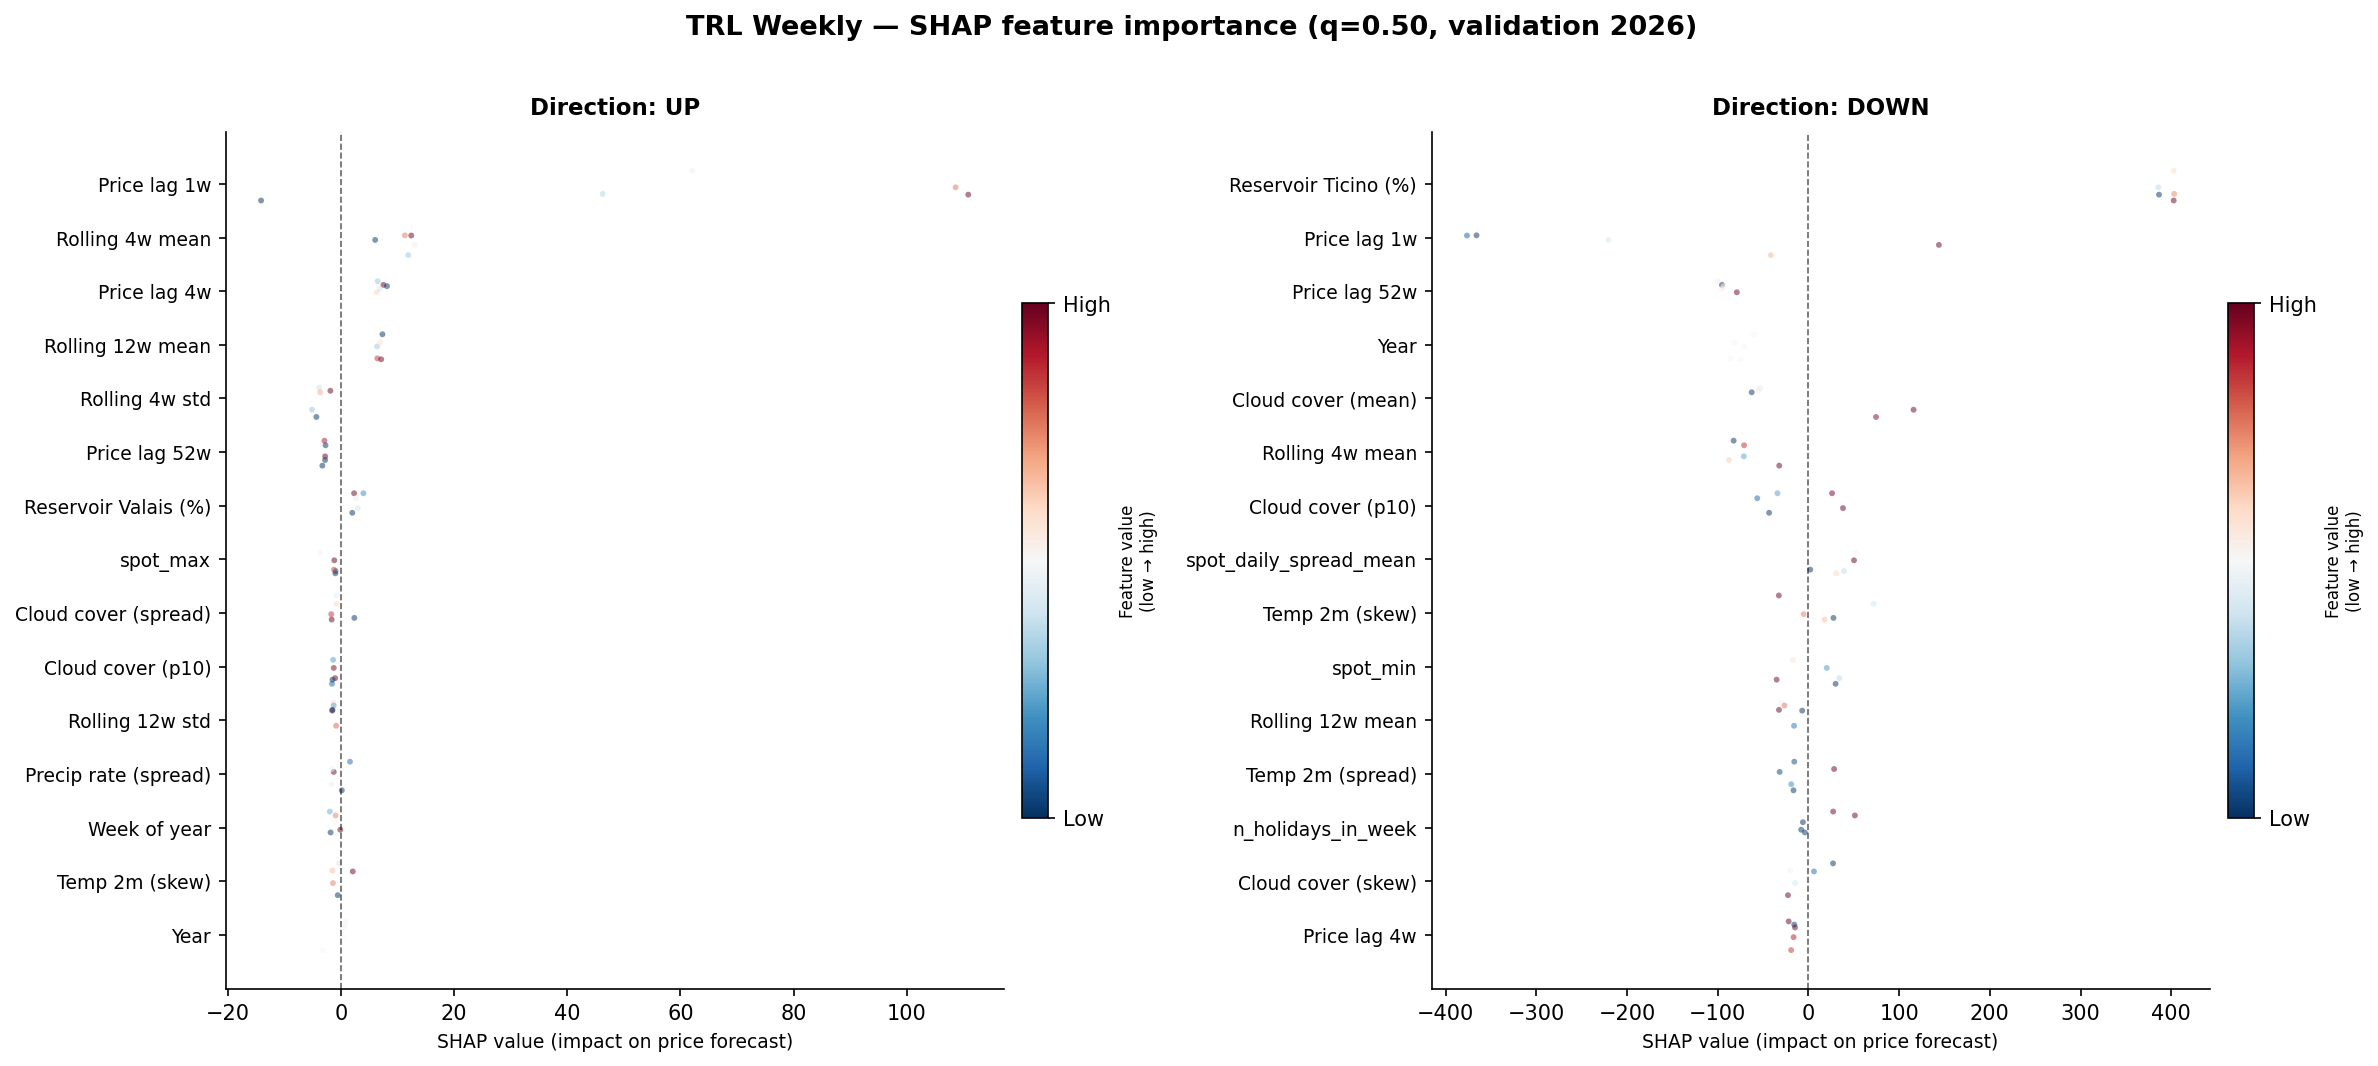


TRL Daily


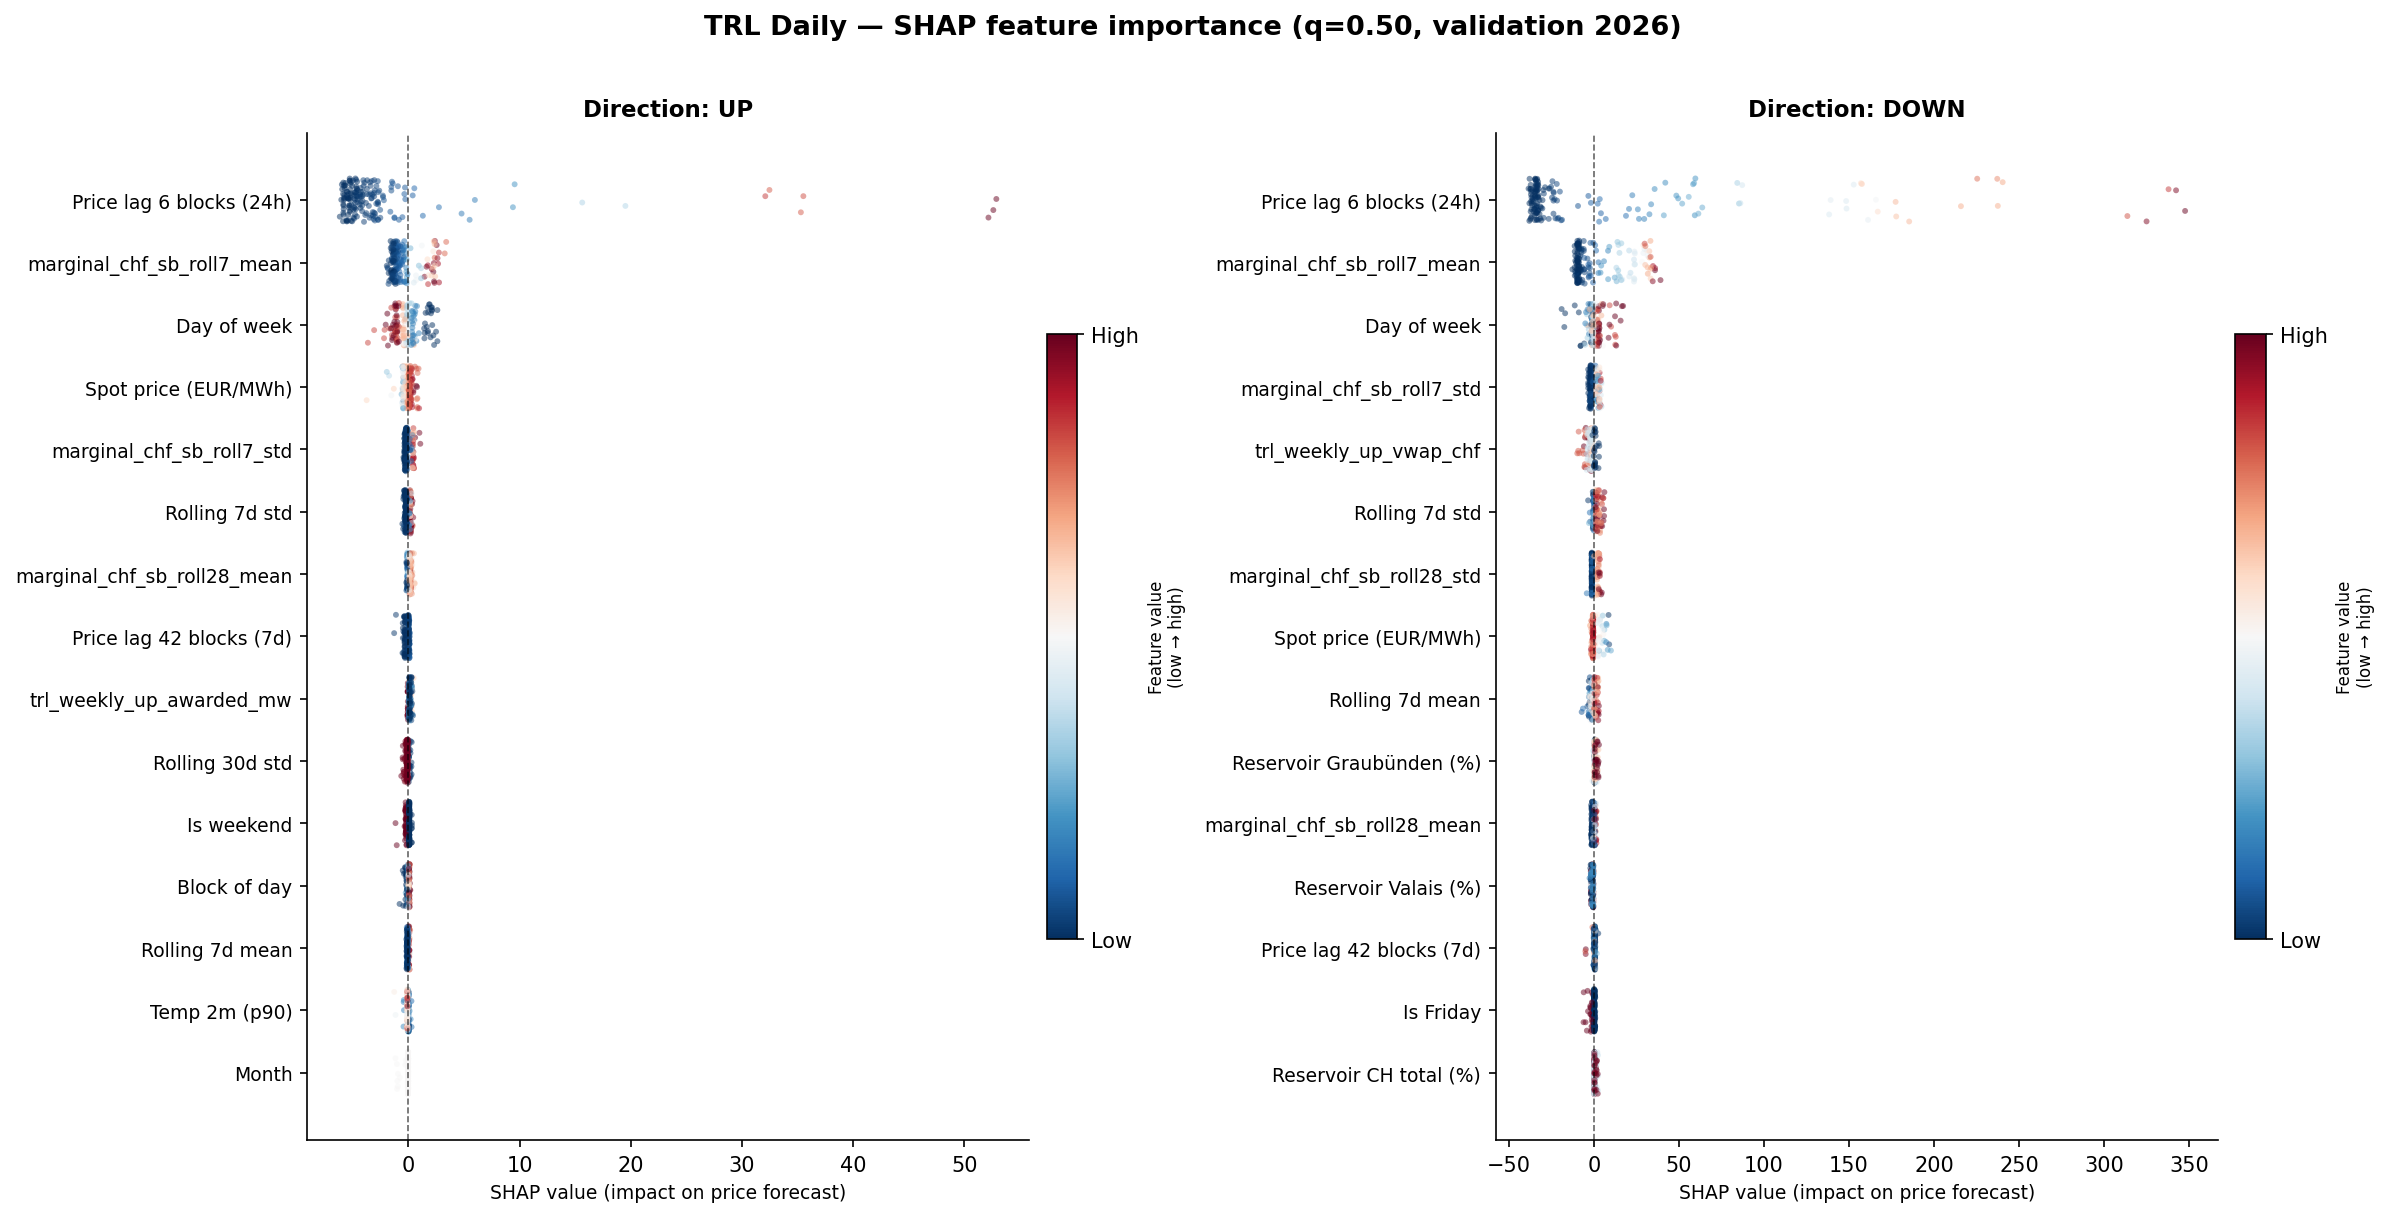


TRE — Normal regime (q=0.50)


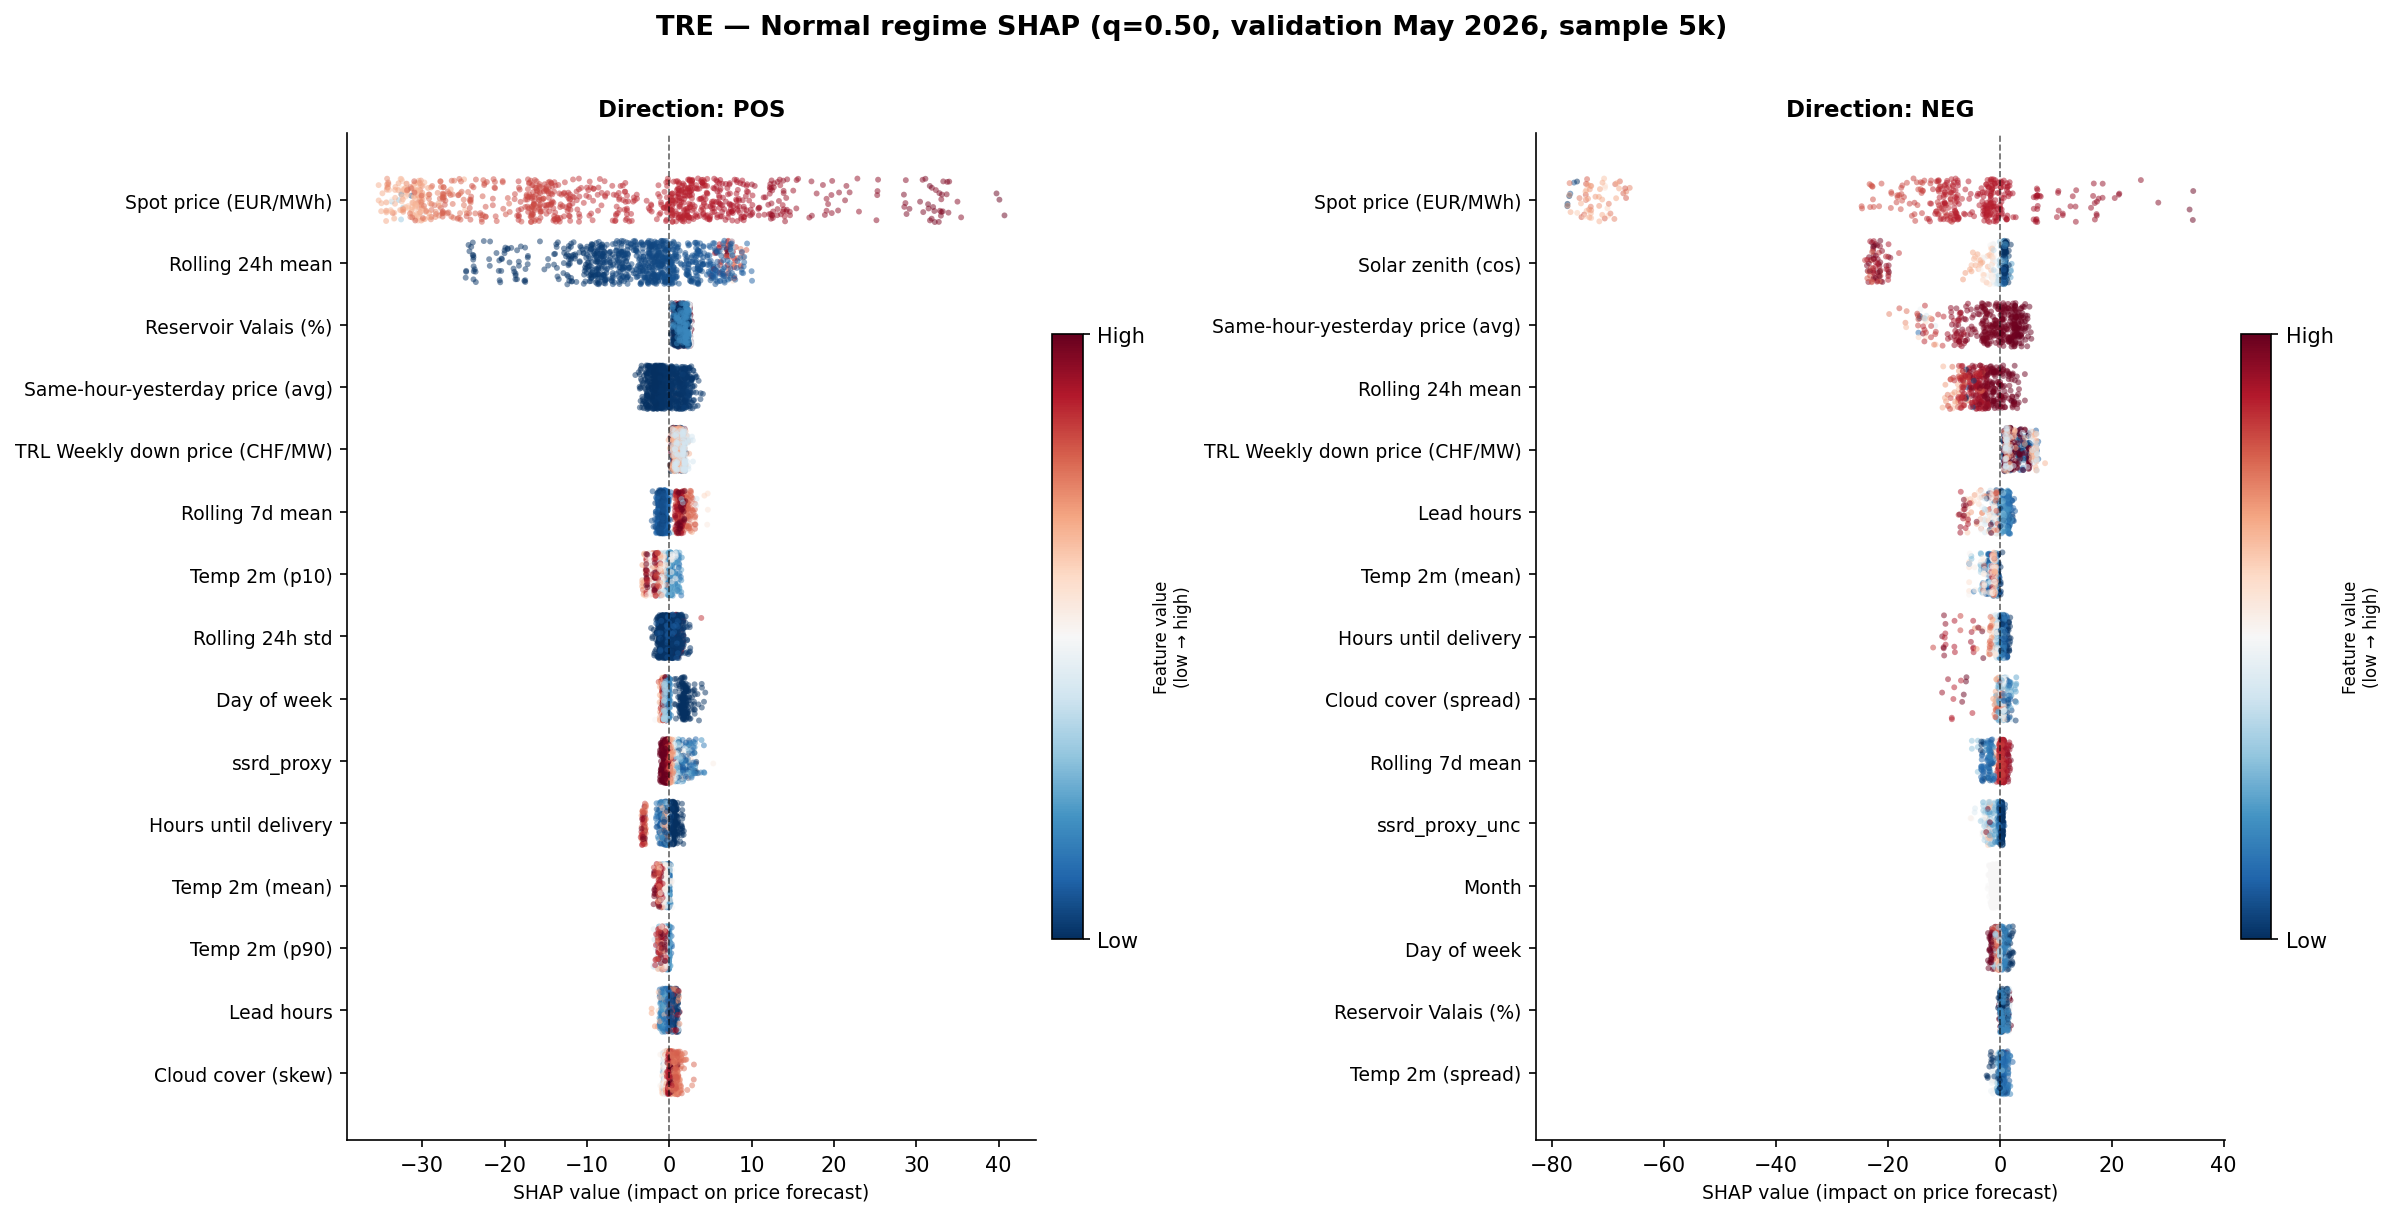


TRE — Classifier P(extreme)


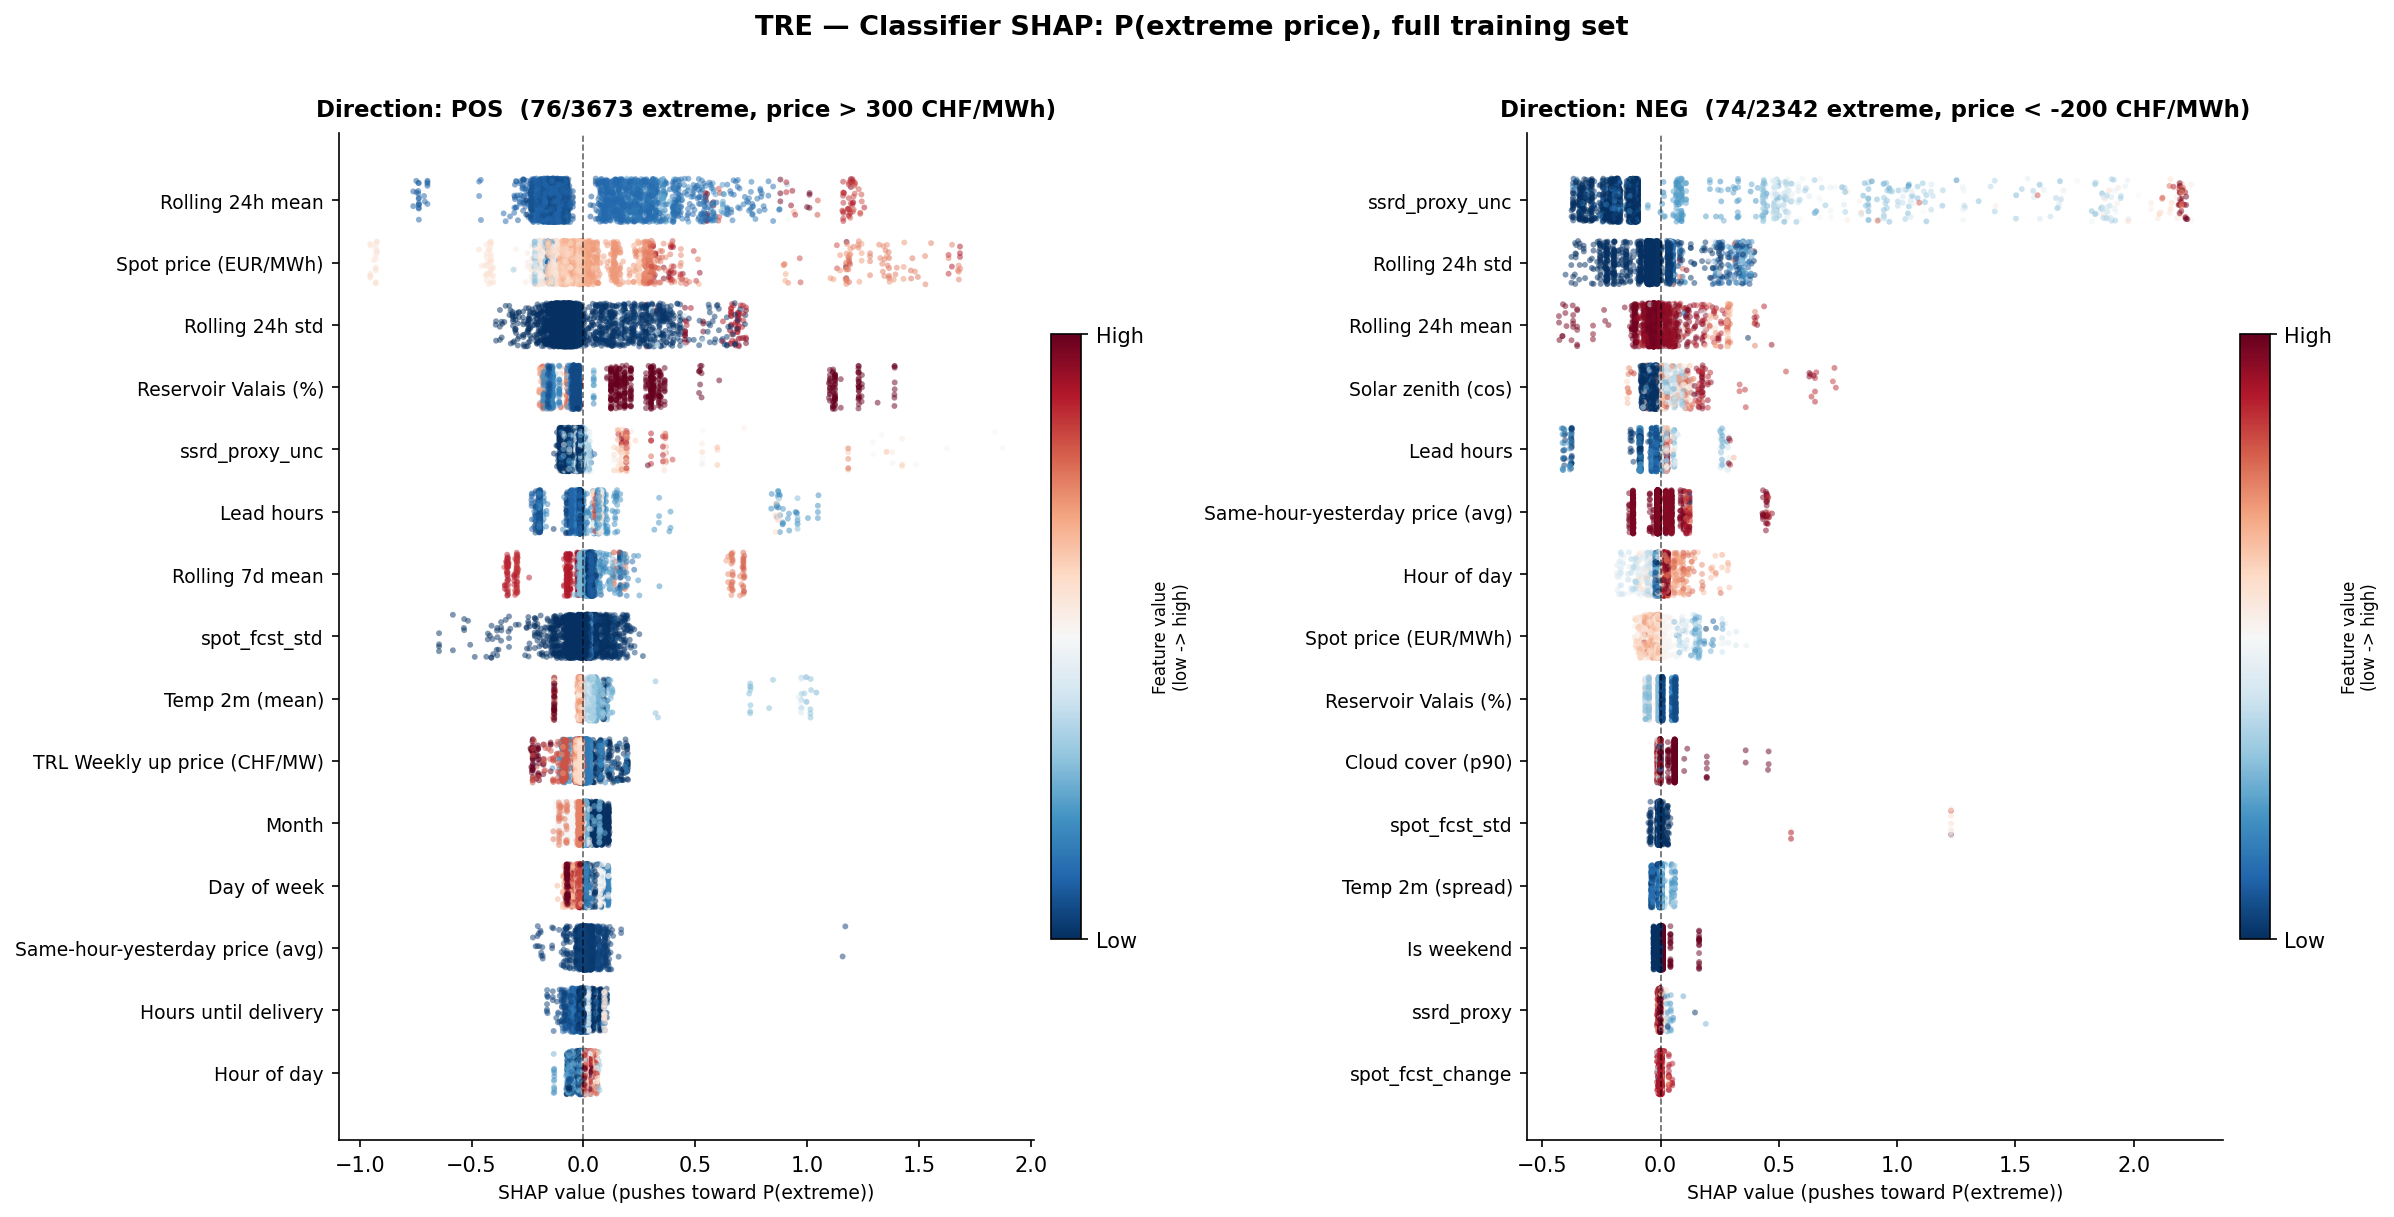

In [34]:
from IPython.display import Image, display as ipy_display

figures = ROOT / "notebooks" / "figures"

for title, fname in [
    ("TRL Weekly",                   "shap_trl_weekly.png"),
    ("TRL Daily",                    "shap_trl_daily.png"),
    ("TRE — Normal regime (q=0.50)", "shap_tre_normal.png"),
    ("TRE — Classifier P(extreme)",  "shap_tre_classifier.png"),
]:
    path = figures / fname
    if path.exists():
        print(f"\n{title}")
        ipy_display(Image(str(path)))
    else:
        print(f"Missing: {fname}")

---
## Live Inference (with plots)
Runs the same three models as the cloud pipeline (`src/pipeline/inference.py`), but reuses the
**local** `weather_ensemble.parquet` (maintained by the data-update cells above) instead of
re-downloading ECMWF Open Data — so it returns in seconds.

Set `USE_LIVE_DOWNLOAD = True` to instead pull the freshest ECMWF Open Data run (slower; walks
back through recent runs until one is published). Outputs are also written to `output/forecasts/`.

In [35]:
# ── Run inference ─────────────────────────────────────────────────────────────
import sys, json, importlib
from pathlib import Path
import pandas as pd

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

import src.pipeline.bid_strategy as bs
import src.pipeline.inference    as inf
importlib.reload(bs)
importlib.reload(inf)          # reload bs first so inf picks up fresh bid-strategy code

USE_LIVE_DOWNLOAD = False      # False = reuse local weather parquet (fast); True = fetch ECMWF Open Data

now = pd.Timestamp.now(tz="UTC")
cfg = inf._load_cfg()

if USE_LIVE_DOWNLOAD:
    run_date = now.tz_convert("Europe/Zurich").date()
    weather  = inf.download_inference_weather(run_date, run_hour=0)
    wx_init  = "live ECMWF Open Data"
else:
    from src.data.feature_store import load_weather_wide
    _wx = load_weather_wide()
    wx_init = _wx["init_time"].max()
    weather = _wx[_wx["init_time"] == wx_init].reset_index(drop=True)

print(f"Inference @ {now:%Y-%m-%d %H:%M UTC}   weather init = {wx_init}")

weekly_out = inf.infer_trl_weekly(weather, now, cfg)
daily_out  = inf.infer_trl_daily(weather, now, cfg)
tre_out    = inf.infer_tre(weather, now, cfg)

# Mirror the cloud outputs locally (output/ is gitignored)
out_dir = ROOT / "output" / "forecasts"
out_dir.mkdir(parents=True, exist_ok=True)
stamp = {"generated_at": now.strftime("%Y-%m-%dT%H:%M:%SZ"), "weather_run": str(wx_init)}
(out_dir / "trl_weekly_latest.json").write_text(json.dumps({**stamp, **weekly_out}, indent=2))
(out_dir / "trl_daily_latest.json").write_text(json.dumps({**stamp, "blocks": daily_out}, indent=2))
(out_dir / "tre_latest.json").write_text(json.dumps({**stamp, "slots": tre_out}, indent=2))

print(f"  TRL Weekly: delivery {weekly_out['delivery_week_start']}"
      f"  |  TRL Daily: {len(daily_out)} blocks  |  TRE: {len(tre_out)} slots")
print(f"  JSON written → {out_dir.relative_to(ROOT)}")

Inference @ 2026-05-29 08:43 UTC   weather init = 2026-05-27 00:00:00+00:00


2026-05-29 10:43:52,502  INFO      [TRL Weekly] delivery_week=2026-06-07  bid_deadline=2026-06-01
2026-05-29 10:43:58,922  INFO        up  q50=372.6  opt_bid=292.7
2026-05-29 10:43:58,964  INFO        down  q50=1382.6  opt_bid=1063.6
2026-05-29 10:43:58,979  INFO      [TRL Daily] 30 blocks (2026-05-31 → 2026-06-05)
2026-05-29 10:44:11,168  INFO        Forecasted 30 blocks
2026-05-29 10:44:11,217  INFO      [TRE] 282 slots (2026-05-29 09:45 → 2026-06-01 08:00)
2026-05-29 10:44:17,338  INFO        Forecasted 282 slots


  TRL Weekly: delivery 2026-06-08  |  TRL Daily: 30 blocks  |  TRE: 282 slots
  JSON written → output\forecasts


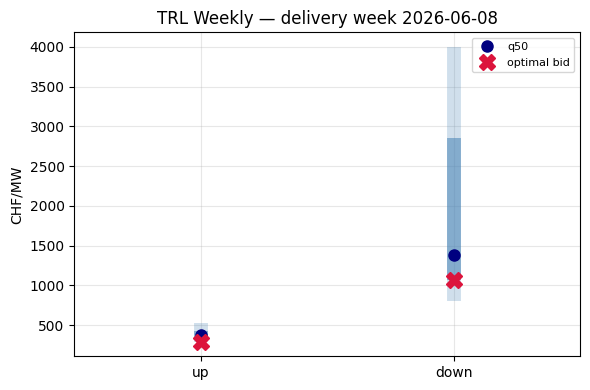

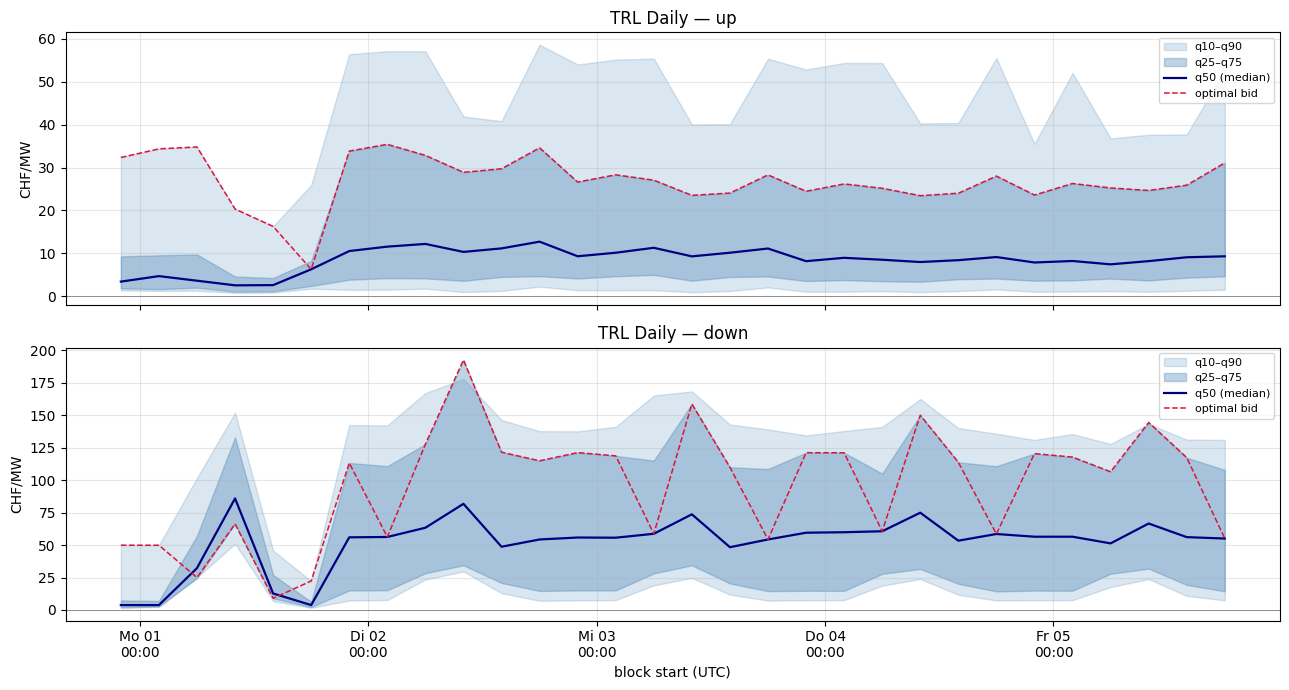

In [36]:
# ── Plot: TRL Weekly + TRL Daily ──────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

QS = ["q10", "q25", "q50", "q75", "q90"]

def _fan_df(slots, time_key, side):
    """list-of-dicts → tidy DataFrame with one row per slot."""
    recs = []
    for s in slots:
        q = s[side]["quantiles"]
        rec = {"t": pd.to_datetime(s[time_key]), **{k: q[k] for k in QS},
               "opt": s[side]["optimal_bid"]}
        if "p_extreme" in s[side]:
            rec["p_extreme"] = s[side]["p_extreme"]
        recs.append(rec)
    return pd.DataFrame(recs)

def _plot_fan(ax, df, title, show_opt=True, unit="CHF/MW"):
    t = df["t"]
    ax.fill_between(t, df["q10"], df["q90"], alpha=0.20, color="steelblue", label="q10–q90")
    ax.fill_between(t, df["q25"], df["q75"], alpha=0.35, color="steelblue", label="q25–q75")
    ax.plot(t, df["q50"], color="navy", lw=1.6, label="q50 (median)")
    if show_opt:
        ax.plot(t, df["opt"], color="crimson", lw=1.1, ls="--", label="optimal bid")
    ax.axhline(0, color="grey", lw=0.6)
    ax.set_title(title); ax.set_ylabel(unit); ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc="upper right")

# TRL Weekly — single delivery week, two directions
fig, ax = plt.subplots(figsize=(6, 4))
for i, d in enumerate(["up", "down"]):
    q = weekly_out[d]["quantiles"]
    ax.vlines(i, q["q10"], q["q90"], color="steelblue", lw=10, alpha=0.25)
    ax.vlines(i, q["q25"], q["q75"], color="steelblue", lw=10, alpha=0.55)
    ax.plot(i, q["q50"], "o", color="navy", ms=8, label="q50" if i == 0 else None)
    ax.plot(i, weekly_out[d]["optimal_bid"], "X", color="crimson", ms=11,
            label="optimal bid" if i == 0 else None)
ax.set_xticks([0, 1]); ax.set_xticklabels(["up", "down"]); ax.set_xlim(-0.5, 1.5)
ax.set_title(f"TRL Weekly — delivery week {weekly_out['delivery_week_start']}")
ax.set_ylabel("CHF/MW"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# TRL Daily — 4-hour blocks over the bid horizon, two directions
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for ax, d in zip(axes, ["up", "down"]):
    _plot_fan(ax, _fan_df(daily_out, "block_start", d), f"TRL Daily — {d}")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%a %d\n%H:%M"))
axes[-1].set_xlabel("block start (UTC)")
plt.tight_layout(); plt.show()

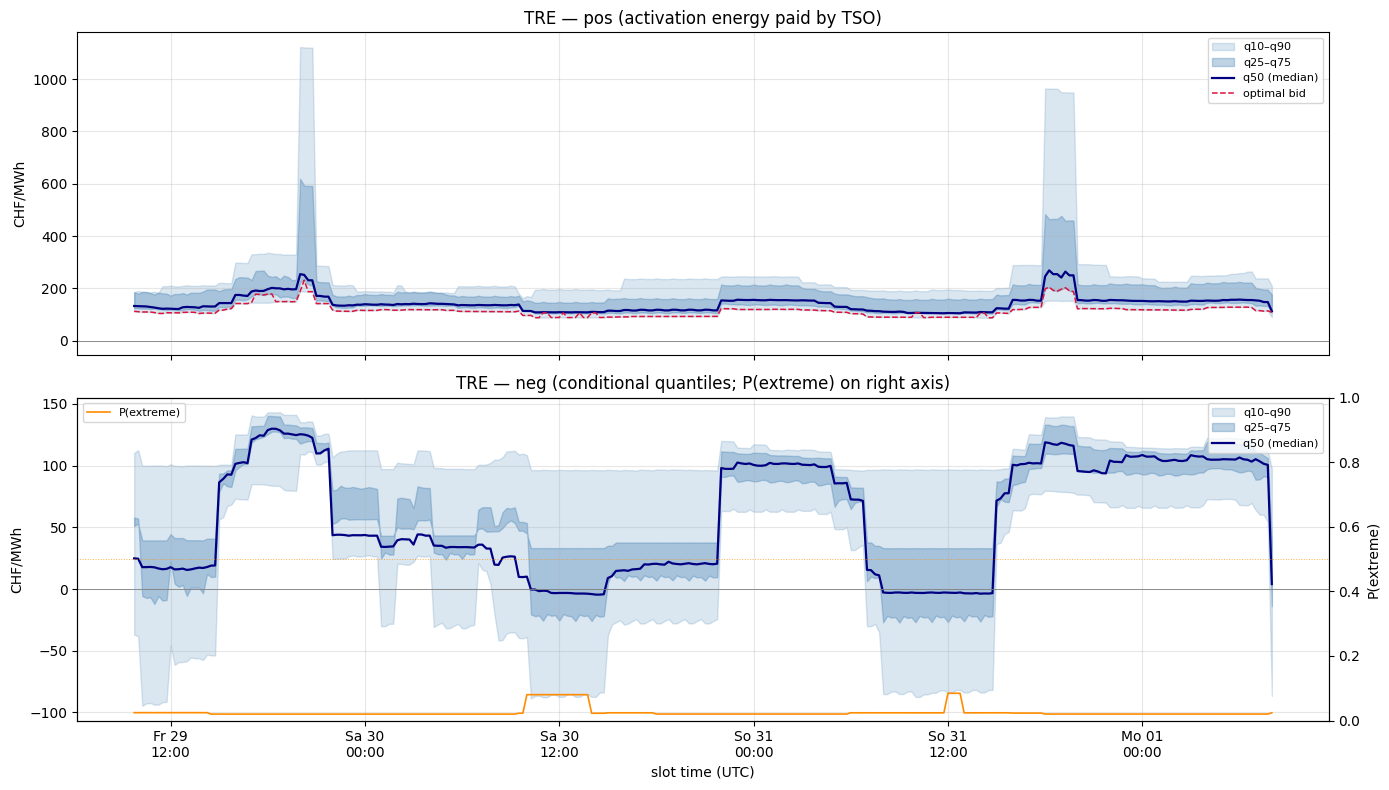

TRE optimal bids (CHF/MWh):
  pos: median 114.9   range [87.4, 231.1]
  neg: median -1765.7   range [-1772.2, -1765.7]
  neg P(extreme): median 0.020   max 0.084


In [37]:
# ── Plot: TRE (15-min slots) ──────────────────────────────────────────────────
# pos: quantile fan + optimal bid on one axis.
# neg: displayed quantiles are CONDITIONAL on the regime the classifier picked
#      (normal model when p_extreme<0.5, extreme model otherwise). The optimal bid
#      (~-1900) lives on the extreme scale, so it is shown separately, not on the
#      quantile axis. P(extreme) is overlaid on a twin axis for context.
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

df_pos = _fan_df(tre_out, "slot_time", "pos")
_plot_fan(axes[0], df_pos, "TRE — pos (activation energy paid by TSO)", unit="CHF/MWh")

df_neg = _fan_df(tre_out, "slot_time", "neg")
_plot_fan(axes[1], df_neg, "TRE — neg (conditional quantiles; P(extreme) on right axis)",
          show_opt=False, unit="CHF/MWh")
ax2 = axes[1].twinx()
ax2.plot(df_neg["t"], df_neg["p_extreme"], color="darkorange", lw=1.2, label="P(extreme)")
ax2.axhline(0.5, color="darkorange", lw=0.7, ls=":", alpha=0.7)
ax2.set_ylabel("P(extreme)"); ax2.set_ylim(0, 1)
ax2.legend(fontsize=8, loc="upper left")

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%a %d\n%H:%M"))
axes[-1].set_xlabel("slot time (UTC)")
plt.tight_layout(); plt.show()

# Quick numeric peek — optimal bids span both regimes
print("TRE optimal bids (CHF/MWh):")
print(f"  pos: median {df_pos['opt'].median():.1f}   range [{df_pos['opt'].min():.1f}, {df_pos['opt'].max():.1f}]")
print(f"  neg: median {df_neg['opt'].median():.1f}   range [{df_neg['opt'].min():.1f}, {df_neg['opt'].max():.1f}]")
print(f"  neg P(extreme): median {df_neg['p_extreme'].median():.3f}   max {df_neg['p_extreme'].max():.3f}")